# **Recruiting Process Analysis Workflow**

Define the primary organizational questions:

Is the recruiting process effective?
Which factors most influence hiring?
Are the interview stages internally consistent?
Does the aptitude test provide unique value?
Are there gender differences at any stage of the process?
If gender differences exist, where in the pipeline do they emerge?

In [1]:
# data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistical tests
from scipy import stats

# statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

# diagnostics
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# sklearn metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# display settings
pd.set_option('display.max_columns', None)

# plotting style
sns.set_style("whitegrid")

**Data Understanding & Variable Classification**

| Variable               | Type               | Role                      |
| ---------------------- | ------------------ | ------------------------- |
| `hired`                | binary 0/1         | final outcome             |
| `gender`               | binary categorical | fairness / group variable |
| `sat`                  | continuous         | applicant attribute       |
| `gpa`                  | continuous         | applicant attribute       |
| `apttest`              | continuous         | aptitude measure          |
| `int1`, `int2`, `int3` | ordinal 1–5        | process-stage ratings     |


In [2]:
# load recruiting dataset
url = "https://raw.githubusercontent.com/keithmcnulty/peopleanalytics-regression-book/master/data/recruiting.csv"

recruiting_df = pd.read_csv(url)

# basic inspection
print(recruiting_df.shape)
print("\nColumns:")
print(recruiting_df.columns)

# preview data
recruiting_df.head()

(966, 8)

Columns:
Index(['gender', 'sat', 'gpa', 'apttest', 'int1', 'int2', 'int3', 'hired'], dtype='object')


,gender,sat,gpa,apttest,int1,int2,int3,hired
0,F,1230,3.57,70,4,3,4,0
1,F,1250,3.58,20,3,4,3,0
2,F,930,2.89,77,2,3,3,0
3,F,1110,3.49,85,5,3,4,0
4,M,1260,3.39,93,3,4,4,1


**Exploratory Data Analysis (EDA)**

In [3]:
# check data types
recruiting_df.dtypes

,0
gender,object
sat,int64
gpa,float64
apttest,int64
int1,int64
int2,int64
int3,int64
hired,int64


In [4]:
# check for missing values
recruiting_df.isnull().sum()

,0
gender,0
sat,0
gpa,0
apttest,0
int1,0
int2,0
int3,0
hired,0


In [5]:
# summary statistics
recruiting_df.describe()

,sat,gpa,apttest,int1,int2,int3,hired
count,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000,966.000000
mean,1105.507246,3.379907,62.253623,3.257764,3.507246,3.412008,0.192547
std,200.618478,0.231542,17.265403,0.777146,0.587829,0.525042,0.394504
min,420.000000,2.460000,8.000000,1.000000,2.000000,2.000000,0.000000
25%,970.000000,3.260000,51.000000,3.000000,3.000000,3.000000,0.000000
50%,1110.000000,3.450000,62.000000,3.000000,4.000000,3.000000,0.000000
75%,1257.500000,3.550000,76.000000,4.000000,4.000000,4.000000,0.000000
max,1600.000000,3.870000,99.000000,5.000000,5.000000,5.000000,1.000000


In [6]:
# class balance for hired outcome
recruiting_df["hired"].value_counts()

,count
hired,
0,780
1,186


In [7]:
# proportion hired
recruiting_df["hired"].value_counts(normalize=True)

,proportion
hired,
0,0.807453
1,0.192547


In [8]:
# gender distribution
recruiting_df["gender"].value_counts()

,count
gender,
F,494
M,472


**Preliminary relationship analysis**

**Collinearity Assessment**

In [9]:
# correlation matrix for numerical variables
corr_matrix = recruiting_df[
    ["sat", "gpa", "apttest", "int1", "int2", "int3", "hired"]
].corr()

corr_matrix

,sat,gpa,apttest,int1,int2,int3,hired
sat,1.000000,0.629618,0.288773,0.043261,0.105811,0.026446,0.115295
gpa,0.629618,1.000000,0.143968,0.048739,0.052273,0.027167,0.101164
apttest,0.288773,0.143968,1.000000,0.168662,0.122191,0.088486,0.348375
int1,0.043261,0.048739,0.168662,1.000000,0.155829,0.107707,0.446351
int2,0.105811,0.052273,0.122191,0.155829,1.000000,0.087687,0.414024
int3,0.026446,0.027167,0.088486,0.107707,0.087687,1.000000,0.186943
hired,0.115295,0.101164,0.348375,0.446351,0.414024,0.186943,1.000000


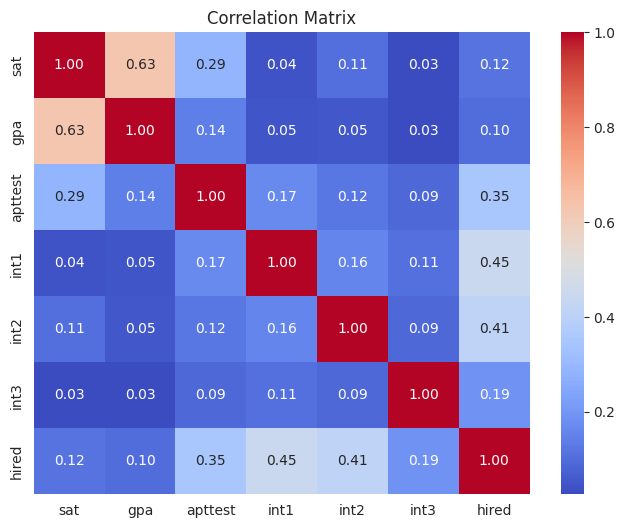

In [10]:
# visualize correlation matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

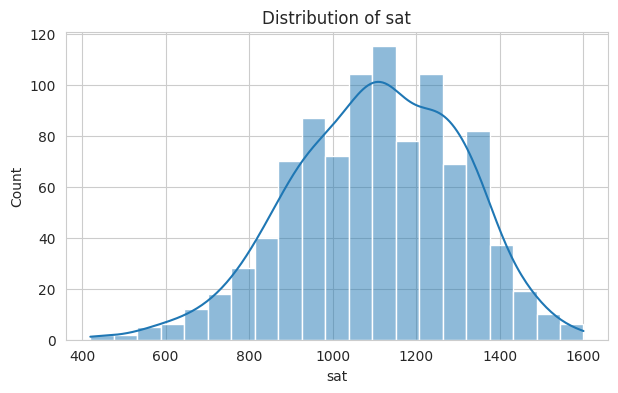

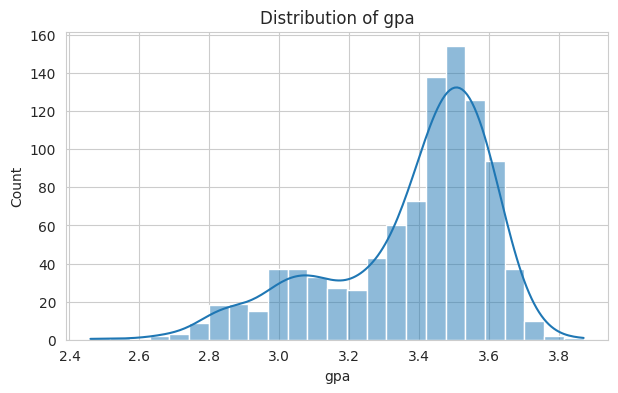

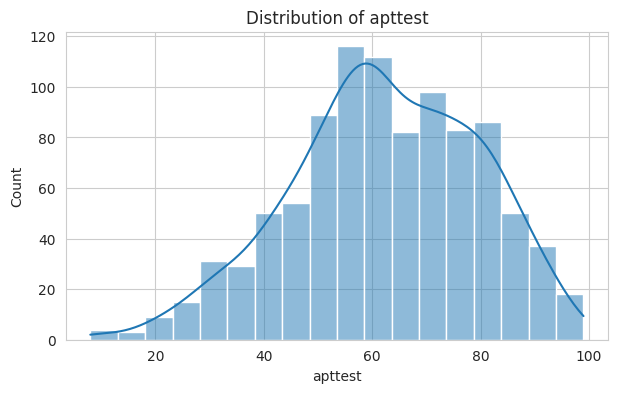

In [11]:
# distributions of continuous variables
continuous_vars = ["sat", "gpa", "apttest"]

for col in continuous_vars:

    plt.figure(figsize=(7, 4))

    sns.histplot(recruiting_df[col], kde=True)

    plt.title(f"Distribution of {col}")

    plt.show()

At this stage, we do not know:

*   whether the difference is statistically significant,
*   whether it disappears after controlling for qualifications,
*  or whether it emerges from a specific stage of the process.

In [12]:
# hiring outcome by gender
pd.crosstab(
    recruiting_df["gender"],
    recruiting_df["hired"],
    margins=True
)

hired,0,1,All
gender,,,
F,416,78,494
M,364,108,472
All,780,186,966


**Assumptions & pre-model diagnostic checks**

SAT and GPA explain very little of the variation in aptitude test scores.

That strongly suggests the aptitude test is NOT simply redundant with SAT and GPA.


For each 1-point increase in SAT, aptitude score increases by about 0.028 points on average, holding GPA constant. The relationship is statistically significant but practically modest.


This model provides evidence that:

*   aptitude test captures something different from GPA,
*   and only partially overlaps with SAT.

In [13]:
# baseline OLS model for aptitude test
apttest_model = smf.ols(
    formula="apttest ~ sat + gpa",
    data=recruiting_df
).fit()

# display results
print(apttest_model.summary())

                            OLS Regression Results                            
Dep. Variable:                apttest   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     45.17
Date:                Tue, 12 May 2026   Prob (F-statistic):           1.78e-19
Time:                        23:48:07   Log-Likelihood:                -4078.7
No. Observations:                 966   AIC:                             8163.
Df Residuals:                     963   BIC:                             8178.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     46.8271      8.181      5.724      0.0

**Model selection and fitting**



The model suggests the line manager ratings are much more strongly associated with final hiring decisions than the HR rating.

In [14]:
# full logistic regression model for hiring outcome
hire_model_full = smf.logit(
    formula="hired ~ sat + gpa + apttest + int1 + int2 + int3",
    data=recruiting_df
).fit()

# display results
print(hire_model_full.summary())

Optimization terminated successfully.
         Current function value: 0.208798
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  hired   No. Observations:                  966
Model:                          Logit   Df Residuals:                      959
Method:                           MLE   Df Model:                            6
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.5738
Time:                        23:48:08   Log-Likelihood:                -201.70
converged:                       True   LL-Null:                       -473.24
Covariance Type:            nonrobust   LLR p-value:                4.383e-114
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -36.2036      3.561    -10.165      0.000     -43.184     -29.223
sat           -0.0015      0.

In [15]:
# convert log-odds coefficients to odds ratios
np.exp(hire_model_full.params)

,0
Intercept,1.892158e-16
sat,9.985114e-01
gpa,2.962345e+00
apttest,1.079542e+00
int1,1.587893e+01
int2,5.281390e+01
int3,1.990894e+00


**Nested Model Comparisons**

Stakeholder Question:
**“Is the aptitude test adding meaningful information?”**

A reduced model that exludes the aptitude test variable will help to answer this question.

In [16]:
# reduced logistic model without aptitude test
hire_model_reduced = smf.logit(
    formula="hired ~ sat + gpa + int1 + int2 + int3",
    data=recruiting_df
).fit()

print(hire_model_reduced.summary())

Optimization terminated successfully.
         Current function value: 0.250830
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  hired   No. Observations:                  966
Model:                          Logit   Df Residuals:                      960
Method:                           MLE   Df Model:                            5
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.4880
Time:                        23:51:20   Log-Likelihood:                -242.30
converged:                       True   LL-Null:                       -473.24
Covariance Type:            nonrobust   LLR p-value:                 1.349e-97
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -31.6251      3.079    -10.271      0.000     -37.660     -25.590
sat            0.0001      0.

Reduced Model Observations

*   interviews with hiring managers remain robust and are the most important predictors

*   int1 and in2 are not highly dependent on whether aptitude testing is included

*   SAT becomes even weaker and GPA remains fairly stable and insignificant. This further supports the idea that SAT contributes little unique information once the later-stage process variables are included.


Pseudo-R^2 Analysis

*   There was a meaningful drop in the Psuedo r^2 value of the reduced model, meaning The reduced model has less explanatory power after remvoving aptitude test.

*   So the aptitude test adds substantial explanatory value.


Why AIC/BIC improved despite greater complexity

*   AIC and BIC penalize complexity. Adding variables only improves AIC/BIC if the added variable improves fit enough to justify the extra complexity. That is exactly what happened here.

*   The aptitude test improved the model so much that the fit improvement outweighed the complexity penalty. This is further strong evidence the aptitude test is useful.




In [18]:
# compare model fit statistics
comparison_df = pd.DataFrame({
    "Model": ["Reduced", "Full"],
    "Pseudo_R2": [
        hire_model_reduced.prsquared,
        hire_model_full.prsquared
    ],
    "AIC": [
        hire_model_reduced.aic,
        hire_model_full.aic
    ],
    "BIC": [
        hire_model_reduced.bic,
        hire_model_full.bic
    ]
})

comparison_df

,Model,Pseudo_R2,AIC,BIC
0,Reduced,0.487993,496.60269,525.841673
1,Full,0.573790,417.39752,451.509667


A **likelihood ratio test** (LRT) is a statistical method that compares the goodness-of-fit of two nested models—a complex model and a simplified version of it—to determine if the additional parameters in the complex model significantly improve the model's fit.

We are testing:

H0: The aptitude test adds no explanatory value

vs

HA: The aptitude test improves the model

Results

*   The test statistic: 81.2


We strongly reject the reduced model.

The aptitude test provides statistically significant incremental explanatory value beyond SAT, GPA, and interview scores. This directly answers the stakeholder question.




In [19]:
# likelihood ratio test comparing reduced vs full model
lr_stat = 2 * (
    hire_model_full.llf - hire_model_reduced.llf
)

df_diff = (
    hire_model_full.df_model - hire_model_reduced.df_model
)

p_value = stats.chi2.sf(lr_stat, df_diff)

print(f"Likelihood Ratio Statistic: {lr_stat:.4f}")
print(f"Degrees of Freedom Difference: {df_diff}")
print(f"P-value: {p_value:.6f}")

Likelihood Ratio Statistic: 81.2052
Degrees of Freedom Difference: 1.0
P-value: 0.000000


Conclusion based on nested model comparison.

**The full model is clearly preferable. We have very strong evidence that the aptitude test is NOT redundant.**

**Gender Fairness Analysis**

Is hiring outcome associated with gender?

Start with:

1.   chi-square test of independence
2.   simple logistic regression:

The **Chi-square test of independence**

Purpose of the chi-square test:

*   To determine whether the hiring outcome (hired) is statistically associated with gender, or whether males and females are hired at similar rates in the recruiting process.

Hypotheses:

H0: Hiring outcome is independent of gender

HA: Hiring outcome is associated with gender

In practical terms:

Null hypothesis: males and females have similar hiring distributions.

Alternative hypothesis: hiring distributions differ by gender.

In [20]:
# contingency table
gender_hired_table = pd.crosstab(
    recruiting_df["gender"],
    recruiting_df["hired"]
)

gender_hired_table

hired,0,1
gender,,
F,416,78
M,364,108


Conclusion of the  **Chi-square test of independence**

Reject the null.

There is statistically significant evidence that hiring outcome is associated with gender in this recruiting process.

*   However, this test only establishes that the hiring distributions differ by gender.


This does *not* yet establish discrimination, causality, or process bias.

In [21]:
# chi-square test of independence
chi2, p, dof, expected = stats.chi2_contingency(gender_hired_table)

print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p:.6f}")
print(f"Degrees of Freedom: {dof}")

Chi-square Statistic: 7.3589
P-value: 0.006673
Degrees of Freedom: 1


The next step is determining:

*   whether that difference remains after controlling for qualifications and interview stages,

*   and where in the process the difference may emerge.


A simple **logistic regression** can help answer these questions.







In [22]:
# simple logistic regression for hiring by gender
gender_model = smf.logit(
    formula="hired ~ C(gender)",
    data=recruiting_df
).fit()

print(gender_model.summary())

Optimization terminated successfully.
         Current function value: 0.485843
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  hired   No. Observations:                  966
Model:                          Logit   Df Residuals:                      964
Method:                           MLE   Df Model:                            1
Date:                Wed, 13 May 2026   Pseudo R-squ.:                0.008271
Time:                        00:45:34   Log-Likelihood:                -469.32
converged:                       True   LL-Null:                       -473.24
Covariance Type:            nonrobust   LLR p-value:                  0.005144
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.6740      0.123    -13.567      0.000      -1.916      -1.432
C(gender)[T.M]   

In [23]:
# odds ratios
np.exp(gender_model.params)

,0
Intercept,0.187500
C(gender)[T.M],1.582418


**Results of chi-sqaured and logistic regression tests for gender.**

At this stage, we cannot conclude that there is gender bias.

What we can say is that there is a statistically significant association between gender and hiring outcome in the raw, unadjusted analysis.

Add gender into the full hiring model, then see whether the gender effect remains after controlling for the other predictors.

That moves us from “are outcomes different?” to “are outcomes different after accounting for qualifications and evaluations?”

In [24]:
# full hiring model including gender
hire_model_gender = smf.logit(
    formula="""
    hired ~ gender + sat + gpa + apttest + int1 + int2 + int3
    """,
    data=recruiting_df
).fit()

print(hire_model_gender.summary())

Optimization terminated successfully.
         Current function value: 0.208131
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                  hired   No. Observations:                  966
Model:                          Logit   Df Residuals:                      958
Method:                           MLE   Df Model:                            7
Date:                Wed, 13 May 2026   Pseudo R-squ.:                  0.5752
Time:                        00:55:22   Log-Likelihood:                -201.05
converged:                       True   LL-Null:                       -473.24
Covariance Type:            nonrobust   LLR p-value:                2.300e-113
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -36.1752      3.571    -10.131      0.000     -43.174     -29.177
gender[T.M]     0.2886    

In [25]:
# odds ratios for full model including gender
np.exp(hire_model_gender.params)

,0
Intercept,1.946761e-16
gender[T.M],1.334596e+00
sat,9.985509e-01
gpa,2.865192e+00
apttest,1.078456e+00
int1,1.566481e+01
int2,5.254064e+01
int3,2.007081e+00


**Gender analysis logistic regression model conclusion**

We do not find strong evidence of direct gender bias in the final hiring decision after accounting for applicant qualifications and interview evaluations.

This does not completely rule out process bias.

Why?

Because gender effects could still emerge indirectly through interview ratings,aptitude testing, or earlier screening stages.

**Process-Stage Analysis**

So the next logical step would be:

*   model interview stages or aptitude test outcomes using gender,
*   and determine whether gender associations emerge earlier in the pipeline.






After controlling for SAT and GPA, is aptitude test performance associated with gender?


After controlling for SAT and GPA, male applicants score approximately 2.49 points higher on the aptitude test on average, and this difference is statistically significant.

That means the aptitude test is associated with gender even after accounting for academic indicators.




From a process-audit perspective, the aptitude test appears to be one mechanism through which gender differences in hiring outcomes may emerge. Recommend further investigation, but this is *not* a definitive claim of discrimination or bias.

In [26]:
# OLS model for aptitude test by gender
apttest_gender_model = smf.ols(
    formula="apttest ~ gender + sat + gpa",
    data=recruiting_df
).fit()

print(apttest_gender_model.summary())

                            OLS Regression Results                            
Dep. Variable:                apttest   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     32.08
Date:                Wed, 13 May 2026   Prob (F-statistic):           9.07e-20
Time:                        01:03:21   Log-Likelihood:                -4076.0
No. Observations:                 966   AIC:                             8160.
Df Residuals:                     962   BIC:                             8179.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      45.5903      8.179      5.574      

**Organizational interpretation & recommendations**

The analysis evaluated which elements of the recruiting process were most strongly associated with hiring outcomes and whether any gender differences emerged throughout the process. Exploratory analysis showed that the dataset was clean, balanced across gender, and suitable for statistical modeling. Correlation analysis suggested moderate overlap between SAT and GPA scores, but no evidence of severe multicollinearity among the primary predictors. Initial hiring-rate comparisons indicated that male applicants were hired at higher rates than female applicants in the raw, unadjusted data.
A series of logistic regression models showed that the strongest predictors of hiring were the two line-manager interview ratings (int1 and int2). The human resources interview (int3) remained statistically significant but had a substantially smaller influence on hiring decisions. SAT and GPA provided relatively little explanatory value once the later-stage evaluations and aptitude testing variables were included. Nested model comparisons demonstrated that the aptitude test added substantial incremental explanatory power beyond SAT and GPA alone, indicating that the test was not simply redundant with existing academic indicators.

Further fairness analysis showed that gender was statistically associated with hiring outcomes in the unadjusted model. However, after controlling for SAT, GPA, aptitude test performance, and interview evaluations, the direct gender effect was no longer statistically significant. This suggests that the observed raw hiring differences were largely explained by other variables in the recruiting process rather than strong direct evidence of gender-based decision making in the final hiring stage.

Additional process-level modeling revealed that male applicants scored significantly higher on the aptitude test even after controlling for SAT and GPA. Because the aptitude test was also an important predictor of hiring outcomes, this suggests that the aptitude testing stage may be one pathway through which gender differences emerge within the recruiting pipeline. While these findings do not establish discriminatory bias, they do indicate that the aptitude testing process warrants additional organizational review to determine whether the assessment is measuring job-relevant skills fairly and consistently across applicant groups.

Overall, the analysis suggests that the recruiting process is driven primarily by line-manager interview evaluations, with aptitude testing also playing a meaningful role in hiring decisions. The results do not provide strong evidence of direct gender bias in the final hiring decision after accounting for applicant qualifications and evaluations. However, the aptitude testing stage appears to merit further investigation as part of a broader fairness and process-audit review.